In [4]:
!pip3 install -r requirements.txt


In [8]:
import os
import pandas as pd

DATA_ROOT = "CUB_200_2011"
IMAGES_FILE = os.path.join(DATA_ROOT, "images.txt")
LABELS_FILE = os.path.join(DATA_ROOT, "image_class_labels.txt")
CLASSES_FILE = os.path.join(DATA_ROOT, "classes.txt")
SPLIT_FILE = os.path.join(DATA_ROOT, "train_test_split.txt")

required = [IMAGES_FILE, LABELS_FILE, CLASSES_FILE, SPLIT_FILE]
for f in required:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Отсутствует файл датасета: {f}. Убедитесь, что CUB_200_2011 уже распакован в корне проекта.")

images = pd.read_csv(IMAGES_FILE, sep=" ", header=None, names=["image_id", "file_path"])
labels = pd.read_csv(LABELS_FILE, sep=" ", header=None, names=["image_id", "class_id"])
classes = pd.read_csv(CLASSES_FILE, sep=" ", header=None, names=["class_id", "class_name_raw"])
split = pd.read_csv(SPLIT_FILE, sep=" ", header=None, names=["image_id", "is_training"])

meta = (
    images
    .merge(labels, on="image_id")
    .merge(classes, on="class_id")
    .merge(split, on="image_id")
)
meta["class_name"] = (
    meta["class_name_raw"].str.split(".", n=1).str[1].str.replace("_", " ")
)
meta["image_path"] = meta["file_path"].apply(lambda p: os.path.join(DATA_ROOT, "images", p))

meta.to_csv("bird_data.csv", index=False)
print("Сохранен bird_data.csv, строк:", len(meta))
print(meta.head())


Сохранен bird_data.csv, строк: 11788
   image_id                                          file_path  class_id  \
0         1  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
1         2  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
2         3  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
3         4  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
4         5  001.Black_footed_Albatross/Black_Footed_Albatr...         1   

               class_name_raw  is_training              class_name  \
0  001.Black_footed_Albatross            0  Black footed Albatross   
1  001.Black_footed_Albatross            1  Black footed Albatross   
2  001.Black_footed_Albatross            0  Black footed Albatross   
3  001.Black_footed_Albatross            1  Black footed Albatross   
4  001.Black_footed_Albatross            1  Black footed Albatross   

                                          image_path  
0  CUB_200_2011\images\001.Bla

In [ ]:
import pandas as pd

meta = pd.read_csv("bird_data.csv")

N_CLASSES = 1
IMAGES_PER_CLASS_TRAIN = 12

classes_subset = (
    meta.loc[meta["is_training"] == 1, "class_id"]
    .sort_values()
    .unique()[:N_CLASSES]
)

train_subset = (
    meta[(meta["class_id"].isin(classes_subset)) & (meta["is_training"] == 1)]
    .groupby("class_id")
    .head(IMAGES_PER_CLASS_TRAIN)
    .reset_index(drop=True)
)

test_subset = (
    meta[(meta["class_id"].isin(classes_subset)) & (meta["is_training"] == 0)]
    .reset_index(drop=True)
)

train_subset.to_csv("bird_data_train.csv", index=False)
test_subset.to_csv("bird_data_eval.csv", index=False)

print("Train подвыборка сохранена в bird_data_train.csv")
print("Eval подвыборка (test) сохранена в bird_data_eval.csv")
print("Классов в подвыборке:", len(classes_subset))
print("Train size:", len(train_subset), "Eval size:", len(test_subset))
print(train_subset[["image_id", "class_id", "class_name", "image_path" ]].head())


Train подвыборка сохранена в bird_data_train.csv
Eval подвыборка (test) сохранена в bird_data_eval.csv
Классов в подвыборке: 15
Train size: 180 Eval size: 387
   image_id  class_id              class_name  \
0         2         1  Black footed Albatross   
1         4         1  Black footed Albatross   
2         5         1  Black footed Albatross   
3         7         1  Black footed Albatross   
4         8         1  Black footed Albatross   

                                          image_path  
0  CUB_200_2011\images\001.Black_footed_Albatross...  
1  CUB_200_2011\images\001.Black_footed_Albatross...  
2  CUB_200_2011\images\001.Black_footed_Albatross...  
3  CUB_200_2011\images\001.Black_footed_Albatross...  
4  CUB_200_2011\images\001.Black_footed_Albatross...  


Оцениваем на 387 изображениях, классов: 15
Предсказано: Black footed Albatross (уверенность 0.77), истинный класс Black footed Albatross
Предсказано: Black footed Albatross (уверенность 0.80), истинный класс Black footed Albatross
Предсказано: Black footed Albatross (уверенность 0.50), истинный класс Black footed Albatross
Предсказано: Black footed Albatross (уверенность 0.75), истинный класс Black footed Albatross
Предсказано: Black footed Albatross (уверенность 0.82), истинный класс Black footed Albatross
Предсказано: Black footed Albatross (уверенность 0.58), истинный класс Black footed Albatross
Предсказано: Laysan Albatross (уверенность 0.45), истинный класс Black footed Albatross
Предсказано: Black footed Albatross (уверенность 0.87), истинный класс Black footed Albatross
Предсказано: Laysan Albatross (уверенность 0.45), истинный класс Black footed Albatross
Предсказано: Black footed Albatross (уверенность 0.68), истинный класс Black footed Albatross
Предсказано: Black footed Alb

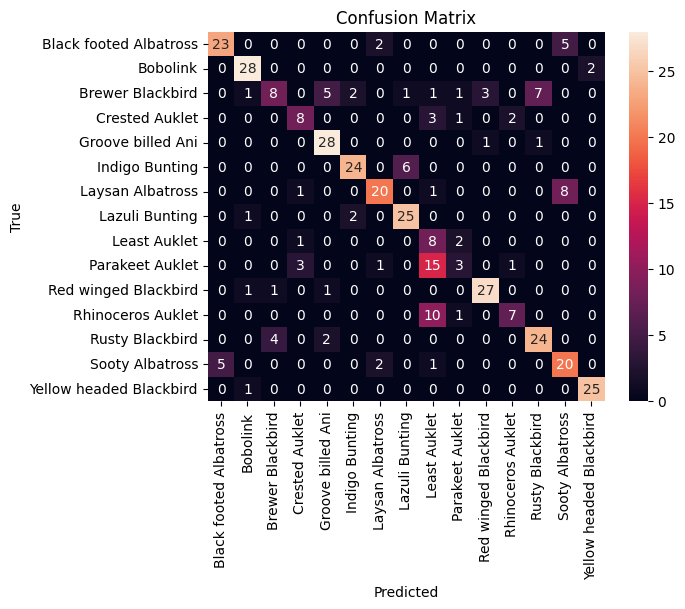

                         precision    recall  f1-score   support

 Black footed Albatross       0.82      0.77      0.79        30
               Bobolink       0.88      0.93      0.90        30
       Brewer Blackbird       0.62      0.28      0.38        29
         Crested Auklet       0.62      0.57      0.59        14
      Groove billed Ani       0.78      0.93      0.85        30
         Indigo Bunting       0.86      0.80      0.83        30
       Laysan Albatross       0.80      0.67      0.73        30
         Lazuli Bunting       0.78      0.89      0.83        28
           Least Auklet       0.21      0.73      0.32        11
        Parakeet Auklet       0.38      0.13      0.19        23
   Red winged Blackbird       0.87      0.90      0.89        30
      Rhinoceros Auklet       0.70      0.39      0.50        18
        Rusty Blackbird       0.75      0.80      0.77        30
        Sooty Albatross       0.61      0.71      0.66        28
Yellow headed Blackbird 

In [10]:
import os
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
import numpy as np

from sklearn.metrics import classification_report

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

EVAL_PATH = "bird_data_eval.csv" if os.path.exists("bird_data_eval.csv") else "bird_data.csv"
df = pd.read_csv(EVAL_PATH)
print(f"Оцениваем на {len(df)} изображениях, классов: {df['class_name'].nunique()}")

labels = sorted(df["class_name"].unique())
prompts_sets = [
    [f"a photo of a {label}" for label in labels],
    [f"an image showing {label}" for label in labels],
    [f"a picture of {label} with typical features" for label in labels],
]

predicted = []

for _, row in df.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")
    all_probs = []
    for prompts in prompts_sets:
        inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]
            all_probs.append(probs)
    avg_probs = np.mean(all_probs, axis=0)
    pred_index = avg_probs.argmax()
    predicted.append(labels[pred_index])
    print(f"Предсказано: {labels[pred_index]} (уверенность {avg_probs[pred_index]:.2f}), истинный класс {row['class_name']}")

results = df.copy()
results["predicted"] = predicted

cm = confusion_matrix(results['class_name'], results['predicted'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(results['class_name'], results['predicted'], zero_division=0))
